# Snippet - Regressão de Menor Ângulo
A regressão de ângulo mínimo (LARS) é um algoritmo de regressão para dados de alta dimensão. LARS é semelhante à regressão stepwise direta. A cada passo, ele encontra o recurso mais correlacionado com o alvo. Quando existem vários recursos com correlação igual, em vez de continuar ao longo do mesmo recurso, ele prossegue em uma direção equiangular entre os recursos.

A figura abaixo representa o caminho prosseguido pelo algoritmo.

<img src="./img/LARS_plot.png" alt="Plot de exemplo caminho do LASSO LARS." style="height:300px;">
</br></br>

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
# Data
data = {
    "x1": [1, 2, 3, 4, 5],
    "x2": [5, 10, 15, 20, 25],           # Relação linear com x1
    "x3": [3, 6, 2, 8, 5],               # Valores variados
    "x4": [4, 16, 36, 64, 100],          # Relação quadrática
    "x5": [7, 6, 4, 2, 1],               # Decrescente
    "y":  [20, 35, 50, 85, 140]          # Combinação linear + ruído
}

df = pd.DataFrame(data)

In [3]:
# Fit
lg = linear_model.LassoLars(alpha=0.1)
lg.fit(df[["x1","x2","x3","x4","x5"]],df["y"])

,alpha,0.1
,fit_intercept,True
,verbose,False
,precompute,'auto'
,max_iter,500
,eps,np.float64(2....049250313e-16)
,copy_X,True
,fit_path,True
,positive,False
,jitter,None
,random_state,None


In [4]:
# Attributes
print(f'Intercept: {lg.intercept_}\nCoeficients:{lg.coef_}')

Intercept: -52.32926518115457
Coeficients:[0.         0.         0.50035082 1.80451607 9.13221849]


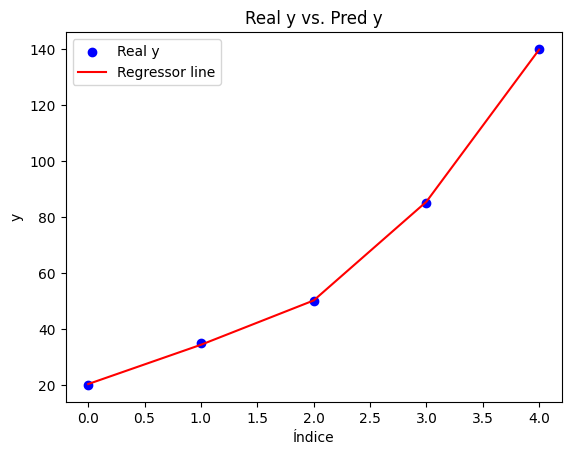

In [5]:
# Prep
X = df[["x1","x2","x3","x4","x5"]]
y = df["y"]
y_pred = lg.intercept_ + np.dot(X, lg.coef_)

# Viz
plt.scatter(range(len(y)), y, color='blue', label='Real y')
plt.plot(range(len(y_pred)), y_pred, color='red', label='Regressor line')
plt.xlabel('Índice')
plt.ylabel('y')
plt.legend()
plt.title('Real y vs. Pred y')
plt.show()